#E-Ticaret Teslimat ve Müşteri Deneyimi Analizi

#### Proje Hakkında

Bu projede bir e-ticaret platformuna ait farklı veri setleri analiz edilerek müşteri davranışları, satış süreçleri, teslimat performansı, ürün özellikleri, satıcı performansları ve müşteri memnuniyeti arasındaki ilişkiler incelenmiştir.

Projenin amacı yalnızca verileri görselleştirmek değil, aynı zamanda veri odaklı iş içgörüleri elde ederek operasyonel süreçleri ve müşteri deneyimini daha iyi anlamaktır.




#Veri Yükleme

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [ ]:
customers   = pd.read_csv("/content/drive/MyDrive/olist_customers_dataset.csv")
orders      = pd.read_csv("/content/drive/MyDrive/olist_orders_dataset.csv")
order_items = pd.read_csv("/content/drive/MyDrive/olist_order_items_dataset.csv")
payments    = pd.read_csv("/content/drive/MyDrive/olist_order_payments_dataset.csv")
reviews     = pd.read_csv("/content/drive/MyDrive/olist_order_reviews_dataset.csv")
products    = pd.read_csv("/content/drive/MyDrive/olist_products_dataset.csv")
sellers     = pd.read_csv("/content/drive/MyDrive/olist_sellers_dataset.csv")

In [ ]:
datasets = {
"customers": customers,
"orders": orders,
"order_items": order_items,
"payments": payments,
"reviews": reviews,
"products": products,
"sellers": sellers
}

for name, df in datasets.items():
 print(name, df.shape)

customers (99441, 5)
orders (99441, 8)
order_items (112650, 7)
payments (103886, 5)
reviews (99224, 7)
products (32951, 9)
sellers (3095, 4)


In [ ]:
orders.head()
customers.head()
order_items.head()
payments.head()
reviews.head()
products.head()
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


#Veri keşfi (EDA)

In [ ]:
for name, df in datasets.items():
 print("\n---", name, "---")
 print(df.info())


--- customers ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

--- orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_t

In [ ]:
for name, df in datasets.items():
 print("\n---", name, "missing values ---")
 print(df.isnull().sum())


--- customers missing values ---
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

--- orders missing values ---
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

--- order_items missing values ---
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

--- payments missing values ---
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

--- reviews missing values ---
review_id              

In [ ]:
orders["order_status"].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [ ]:
reviews["review_score"].value_counts().sort_index()

,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


In [ ]:
payments["payment_type"].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


#Veri Temizleme

In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
customers.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [ ]:
orders[orders["order_delivered_customer_date"].isnull()]["order_status"].value_counts()


,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


Eksik teslimat tarihleri incelendiğinde, eksik verilerin büyük kısmının shipped, canceled ve unavailable durumundaki siparişlerden kaynaklandığı görüldü. Bu nedenle bu eksik değerler doğal kabul edildi ve veri setinden kaldırılmadı.

In [ ]:
reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


Review veri setinde eksik değerlerin büyük kısmının yorum başlığı ve yorum mesajı alanlarında olduğu görüldü. Bunun nedeni, bazı kullanıcıların yalnızca puan verip yazılı yorum bırakmamış olması olabilir. Bu nedenle eksik değerler doğal kabul edildi.

In [ ]:
sellers.isnull().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


Customers, payments, items ve sellers veri setlerinde eksik veri bulunmadı
*orders veri setindeki eksiklerin büyük kısmı sipariş durumundan kaynaklanan doğal eksiklerdi
*reviews veri setindeki eksikler kullanıcıların yorum yazmamasından kaynaklandı
*products veri setindeki eksik
satırlar temizlendi

In [ ]:
orders_delivered = orders[orders["order_status"] == "delivered"].copy()

In [ ]:
date_columns = [
"order_purchase_timestamp",
"order_approved_at",
"order_delivered_carrier_date",
"order_delivered_customer_date",
"order_estimated_delivery_date"
]

for col in date_columns:
 orders_delivered[col] = pd.to_datetime(orders_delivered[col])

In [ ]:
orders_delivered["delivery_days"] = (
orders_delivered["order_delivered_customer_date"] -
orders_delivered["order_purchase_timestamp"]
).dt.days

orders_delivered["estimated_delivery_days"] = (
orders_delivered["order_estimated_delivery_date"] -
orders_delivered["order_purchase_timestamp"]
).dt.days

orders_delivered["delay_days"] = (
orders_delivered["order_delivered_customer_date"] -
orders_delivered["order_estimated_delivery_date"]
).dt.days

orders_delivered["is_late"] = np.where(
orders_delivered["delay_days"] > 0,
"Late",
"On Time or Early"
)

In [ ]:
orders_delivered[
[
"order_id",
"delivery_days",
"estimated_delivery_days",
"delay_days",
"is_late"
]
].head()

,order_id,delivery_days,estimated_delivery_days,delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,15,-8.0,On Time or Early
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,19,-6.0,On Time or Early
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,26,-18.0,On Time or Early
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,26,-13.0,On Time or Early
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,12,-10.0,On Time or Early


In [ ]:
merged_df = orders_delivered.copy()

In [ ]:
merged_df = merged_df.merge(
    reviews,
    on="order_id",
    how="left"
)

merged_df = merged_df.merge(
    order_items,
    on="order_id",
    how="left"
)

merged_df = merged_df.merge(
    products,
    on="product_id",
    how="left"
)

merged_df = merged_df.merge(
    payments,
    on="order_id",
    how="left"
)

merged_df = merged_df.merge(
    sellers,
    on="seller_id",
    how="left"
)

merged_df = merged_df.merge(
    customers[[
        "customer_id",
        "customer_city",
        "customer_state"
    ]],
    on="customer_id",
    how="left"
)

In [ ]:
merged_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_days', 'estimated_delivery_days', 'delay_days', 'is_late',
       'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'customer_city', 'customer_state'],
      dtype='object')

In [ ]:
def delivery_performance(x):
    if x <= -5:
        return "Very Early"
    elif x <= 0:
        return "On Time"
    elif x <= 5:
        return "Slight Delay"
    else:
        return "Severe Delay"

orders_delivered["delivery_performance"] = (
    orders_delivered["delay_days"]
    .apply(delivery_performance)
)

#Tanımlayıcı istatistikler

##1-Müşteri Davranışı

In [ ]:
reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


Review score verileri incelendiğinde toplam 99.224 değerlendirme bulunduğu görüldü. Ortalama müşteri memnuniyet puanı (mean) yaklaşık 4.08 olarak hesaplandı. Medyan değerin 5 olması, kullanıcıların büyük bir kısmının en yüksek puanı verdiğini göstermektedir. Minimum puan 1, maksimum puan ise 5 olarak bulundu. Standart sapma değerinin düşük olması ise (1,34) puanların genel olarak yüksek skorlar etrafında toplandığını göstermektedir. Genel olarak müşteri memnuniyet seviyesinin yüksek olduğu söylenebilir.

In [ ]:
reviews["review_score"].value_counts()

,count
review_score,
5,57328
4,19142
1,11424
3,8179
2,3151


Review score dağılımı incelendiğinde en fazla verilen puanın 5 olduğu görüldü. 57 binden fazla kullanıcı en yüksek puanı vermiştir. Bu durum genel müşteri memnuniyetinin yüksek olduğunu göstermektedir. Bununla birlikte, yaklaşık 11 bin kullanıcının 1 puan verdiği görülmektedir. Bu sonuç, bazı müşterilerin ciddi memnuniyetsizlik yaşadığını ve müşteri deneyiminde geliştirilmesi gereken alanlar olabileceğini göstermektedir.

##2-Ürün ve Sipariş


In [ ]:
df_items_products=order_items.merge(products,on='product_id')
df_items_products

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,31.0,232.0,1.0,8950.0,45.0,26.0,38.0
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,43.0,869.0,1.0,967.0,21.0,24.0,19.0
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,56.0,1306.0,1.0,100.0,20.0,20.0,20.0


In [ ]:
df_items_products_orders=df_items_products.merge(orders,on='order_id')
df_items_products_orders

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18 00:00:00
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,31.0,232.0,1.0,8950.0,45.0,26.0,38.0,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01 00:00:00
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,43.0,869.0,1.0,967.0,21.0,24.0,19.0,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10 00:00:00
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,56.0,1306.0,1.0,100.0,20.0,20.0,20.0,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25 00:00:00


In [ ]:
df_delivered = df_items_products_orders[
    df_items_products_orders['order_status'] == 'delivered'
]
df_delivered

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18 00:00:00
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,31.0,232.0,1.0,8950.0,45.0,26.0,38.0,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01 00:00:00
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,43.0,869.0,1.0,967.0,21.0,24.0,19.0,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10 00:00:00
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,56.0,1306.0,1.0,100.0,20.0,20.0,20.0,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25 00:00:00


###Sipariş Analizi

####a-İstatiksel Analiz

In [ ]:
df_delivered['price'].describe()

,price
count,110197.000000
mean,119.980563
std,182.299446
min,0.850000
25%,39.900000
50%,74.900000
75%,134.170000
max,6735.000000


Sipariş fiyatlarının tanımlayıcı istatistikleri incelendiğinde ortalama sipariş fiyatının 119.98 BRL, medyan sipariş fiyatının ise 74.90 BRL olduğu görülmüştür. Ortalama değerin medyandan yüksek olması fiyat dağılımının sağa çarpık olduğunu ve veri setinde az sayıda yüksek fiyatlı ürün bulunduğunu göstermektedir.

Standart sapmanın yüksek olması, platformda farklı fiyat segmentlerinden ürünlerin yer aldığını göstermektedir. Ayrıca maksimum sipariş fiyatının 6735 BRL olması premium segment ürünlerin de platform içerisinde bulunduğunu göstermektedir. Siparişlerin %75’inin 134 BRL altında gerçekleşmesi ise müşteri siparişlerinin büyük ölçüde düşük ve orta fiyat segmentinde yoğunlaştığını ortaya koymaktadır.

####b-Histogram

In [ ]:
px.histogram(
    df_delivered[df_delivered['price'] < 1000],
    x='price',
    nbins=50,
    title='Sipariş Fiyatı Dağılımı (0-1000 BRL)'
)

Histogram incelendiğinde sipariş fiyatlarının büyük bölümünün düşük fiyat aralıklarında yoğunlaştığı görülmektedir. Dağılımın sağ tarafında bulunan uzun kuyruk, veri setinde az sayıda yüksek fiyatlı premium ürün bulunduğunu göstermektedir. Görselleştirme sırasında outlier etkisini azaltmak amacıyla üst fiyat limitleri filtrelenerek ana dağılım daha okunabilir hale getirilmiştir.

In [ ]:
px.box(
    df_delivered,
    y='price',
    title='Sipariş Fiyatı Boxplot'
)

Boxplot analizi sipariş fiyatlarının belirgin şekilde sağa çarpık dağıldığını göstermektedir. Siparişlerin büyük bölümü düşük ve orta fiyat segmentinde yoğunlaşırken veri setinde çok sayıda yüksek fiyatlı outlier bulunmaktadır.

Özellikle premium segment ürünlerin fiyat dağılımının üst kısmında yoğunlaştığı görülmektedir. Bu durum az sayıda yüksek fiyatlı ürünün ortalama sipariş değerini yukarı çektiğini göstermektedir. Premium ürünler düşük satış frekansına sahip olsa da toplam gelir üzerinde önemli etki yaratabilir.

###Sipariş Durumu Analizi

In [ ]:
df_items_products_orders['order_status'].value_counts()
px.pie(
    df_items_products_orders,
    names='order_status',
    title='Sipariş Durumu Dağılımı'
)

Siparişlerin yaklaşık %98’inin başarıyla teslim edildiği görülmüştür. Bu durum, Olist platformunun lojistik ve operasyon süreçlerinde yüksek başarı oranına sahip olduğunu göstermektedir. İptal ve başarısız sipariş oranlarının oldukça düşük olması müşteri deneyimi açısından olumlu bir göstergedir

##3-Kargo Bilgisi

In [ ]:
orders_delivered[["delivery_days", "estimated_delivery_days", "delay_days"]].describe()

,delivery_days,estimated_delivery_days,delay_days
count,96470.000000,96478.000000,96470.000000
mean,12.093604,23.372759,-11.875889
std,9.551380,8.758137,10.182105
min,0.000000,2.000000,-147.000000
25%,6.000000,18.000000,-17.000000
50%,10.000000,23.000000,-12.000000
75%,15.000000,28.000000,-7.000000
max,209.000000,155.000000,188.000000


In [ ]:
print("Average delivery days:", round(orders_delivered["delivery_days"].mean(), 2))
print("Median delivery days:", round(orders_delivered["delivery_days"].median(), 2))
print("Average delay days:", round(orders_delivered["delay_days"].mean(), 2))
print("Late delivery rate:", round((orders_delivered["is_late"] == "Late").mean() * 100, 2), "%")

Average delivery days: 12.09
Median delivery days: 10.0
Average delay days: -11.88
Late delivery rate: 6.77 %


#Görselleştirme

##1-Müşteri Davranışı

###Ödeme Yöntemine Göre Müşteri Memnuniyeti



*payments ve reviews tablolarını join ediyoruz*

In [ ]:
payment_reviews=payments.merge(reviews,on="order_id")
payment_reviews.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,4ce650e117a5b292bf5ea980a61eb61e,1,Não recomendo,"Produto com qualidade ruim, amassado e descasc...",2018-05-10 00:00:00,2018-05-15 23:38:00
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,ad2036caca61484fc435d7e673c020f2,5,NaN,NaN,2018-06-30 00:00:00,2018-07-03 11:23:16
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,bcddfa0f7d2e54cfc74bae4f01b84d92,5,NaN,Aprovada,2017-12-19 00:00:00,2017-12-22 17:55:30
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,c37a0e51e5df82bdb55d38ff0ffb6af3,5,NaN,NaN,2017-12-21 00:00:00,2017-12-21 21:42:31
4,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,5bc7680443b4ef765fec11a8201eeb0c,5,NaN,NaN,2017-12-21 00:00:00,2017-12-22 01:10:39


*ödeme yöntemine göre gruplama yaparak reviwes'ın ortalamasını (mean) alıyoruz*

In [ ]:
payment_review_mean=payment_reviews.groupby("payment_type")["review_score"].mean()
payment_review_mean.head()


,review_score
payment_type,
boleto,4.086631
credit_card,4.087637
debit_card,4.168084
not_defined,1.666667
voucher,4.003804


In [ ]:
fig=px.bar(payment_review_mean.reset_index(),
           x="payment_type",
           y="review_score")
fig.show()

Grafiğe göre müşteri memnuniyeti çoğu ödeme yönteminde yaklaşık 4 puan seviyesinde seyrediyor. En yüksek ortalama debit card kategorisinde görülüyor.
Not_defined kategorisinde memnuniyet puanı oldukça düşük çıkıyor. Ancak bu kategorideki veri sayısı düşük olabilir. Genel olarak ödeme yöntemleri arasında büyük bir memnuniyet farkı yok.

###Taksit Sayısına Göre Müşteri Memnuniyeti


In [ ]:
installment_review_mean=payment_reviews.groupby("payment_installments")["review_score"].mean()
installment_review_mean.head()

,review_score
payment_installments,
0,5.000000
1,4.109749
2,4.109357
3,4.058452
4,4.054686


In [ ]:
fig=px.bar(installment_review_mean.reset_index(),
          x="payment_installments",
          y="review_score")
fig.show()

*“Taksit sayısı arttıkça müşteri memnuniyetinde hafif bir düşüş eğilimi görülüyor.”*

###Teslimat Süresine Göre Müşteri Memnuniyeti

In [ ]:
delivery_reviews = orders.merge(reviews, on="order_id")
delivery_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


orders ve reviews tabloları order_id üzerinden join edildi

In [ ]:
delivery_reviews["order_purchase_timestamp"] = pd.to_datetime(delivery_reviews["order_purchase_timestamp"])
delivery_reviews["order_delivered_customer_date"] = pd.to_datetime(delivery_reviews["order_delivered_customer_date"])

*tarih sütunlarını gerçek tarih formatına çevirdik*

In [ ]:
delivery_reviews["delivery_days"] = (
    delivery_reviews["order_delivered_customer_date"] - delivery_reviews["order_purchase_timestamp"]
).dt.days

*teslimat süresi  = sipariş teslim tarihi-sipariş verilme tarihi*

In [ ]:
fig = px.scatter(
    delivery_reviews,
    x="delivery_days",
    y="review_score"
)

fig.show()

*bu grafikte istediğimiz verimi alamadık* o sebeple *Önce teslimat günlerini kategorilere ayırdık*:

In [ ]:
delivery_reviews["delivery_group"] = pd.cut(
    delivery_reviews["delivery_days"],
    bins=[0, 7, 14, 30, 100],
    labels=["0-7 Gün", "8-14 Gün", "15-30 Gün", "30+ Gün"]
)

*Sonra ortalama memnuniyeti hesapladık:*

In [ ]:
delivery_group_mean = delivery_reviews.groupby("delivery_group")["review_score"].mean()

In [ ]:
fig = px.bar(
    delivery_group_mean.reset_index(),
    x="delivery_group",
    y="review_score"
)

fig.show()

0-14 gün arası: memnuniyet yüksek

15-30 gün arasında: biraz düşüş var

30+ gün : teslimatlarda ciddi düşüş var

In [ ]:
bins = [0, 5, 10, 15, 20, 30, 300]

labels = [
    "0-5 Days",
    "6-10 Days",
    "11-15 Days",
    "16-20 Days",
    "21-30 Days",
    "30+ Days"
]

orders_delivered["delivery_group"] = pd.cut(
    orders_delivered["delivery_days"],
    bins=bins,
    labels=labels
)

In [ ]:
delivery_dist = orders_delivered["delivery_group"] \
    .value_counts() \
    .sort_index()

delivery_dist

,count
delivery_group,
0-5 Days,19227
6-10 Days,32855
11-15 Days,21168
16-20 Days,10708
21-30 Days,8382
30+ Days,4117


##2-Ürün ve Sipariş

###Ürün Kategorisi Analizi

In [ ]:
top_categories = df_delivered.groupby(
    'product_category_name'
)['order_id'].nunique().sort_values(ascending=False).head(10)
top_categories


,order_id
product_category_name,
cama_mesa_banho,9272
beleza_saude,8647
esporte_lazer,7530
informatica_acessorios,6530
moveis_decoracao,6307
utilidades_domesticas,5743
relogios_presentes,5495
telefonia,4093
automotivo,3810


In [ ]:
px.bar(
    top_categories,
    title='En Popüler Kategoriler',
)


Analiz sonucunda ev yaşamı (cama_mesa_banho) ve güzellik-sağlık (beleza_saude) kategorilerinin en yüksek sipariş hacmine sahip olduğu görülmüştür. Bu durum, kullanıcıların günlük ihtiyaç ve yaşam ürünlerine yoğun talep gösterdiğini ortaya koymaktadır. Teknoloji aksesuarları ve spor kategorileri de güçlü performans sergilerken, telefon ve oyuncak kategorileri daha düşük sipariş hacmine sahiptir.

In [ ]:
category_avg = df_delivered.groupby(
    'product_category_name'
)['price'].mean().sort_values(ascending=False)

px.bar(
    category_avg.head(10),
    title='En Yüksek Ortalama Fiyatlı Kategoriler'
)

Sipariş hacmi ile ortalama sipariş değeri arasında önemli farklılıklar gözlemlenmiştir. Ev yaşamı ve kişisel bakım kategorileri yüksek sipariş hacmine sahipken, elektronik ve profesyonel ekipman kategorileri daha yüksek ortalama sipariş değeri üretmektedir. Bu durum, bazı kategorilerin trafik odaklı, bazılarının ise gelir odaklı çalıştığını göstermektedir.

In [ ]:
revenue_by_category = df_delivered.groupby(
    'product_category_name'
)['price'].sum().sort_values(ascending=False)
revenue_by_category
px.bar(
    revenue_by_category.head(10),
    title='En Çok Gelir Getiren Kategoriler'
)

Analiz sonuçlarına göre elektronik kategorileri yüksek ortalama sipariş değerine sahip olsa da toplam gelir açısından güzellik-sağlık ve ev yaşam kategorileri öne çıkmaktadır. Bu durum, yüksek hacimli tekrar satın alımların toplam gelir üzerinde daha büyük etkiye sahip olduğunu göstermektedir

##3-Kargo Bilgileri

###Zaman Aralığına göre Sipariş Sayısı

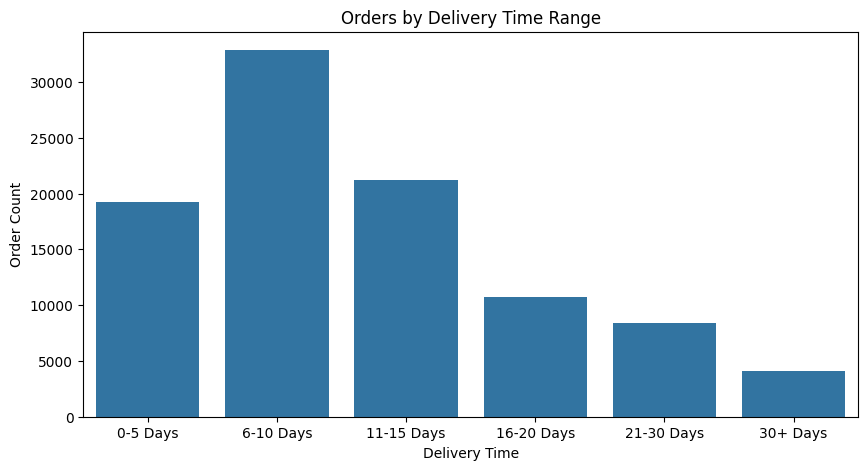

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=delivery_dist.index,
    y=delivery_dist.values
)

plt.title("Orders by Delivery Time Range")
plt.xlabel("Delivery Time")
plt.ylabel("Order Count")

plt.show()

###Teslimat Performansına göre Review Score Değerleri

In [ ]:
def delivery_performance(x):
    if x <= -5:
        return "Very Early"
    elif x <= 0:
        return "On Time"
    elif x <= 5:
        return "Slight Delay"
    else:
        return "Severe Delay"

orders_delivered["delivery_performance"] = (
    orders_delivered["delay_days"]
    .apply(delivery_performance)
)

In [ ]:
merged_df["delivery_performance"] = (
    merged_df["delay_days"]
    .apply(delivery_performance)
)

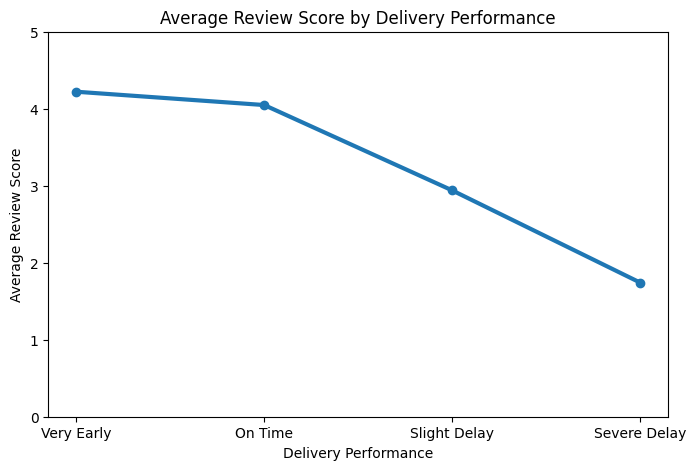

In [ ]:
review_avg = (
    merged_df
    .groupby("delivery_performance")["review_score"]
    .mean()
    .reindex([
        "Very Early",
        "On Time",
        "Slight Delay",
        "Severe Delay"
    ])
)

plt.figure(figsize=(8,5))

plt.plot(
    review_avg.index,
    review_avg.values,
    marker="o",
    linewidth=3
)

plt.title("Average Review Score by Delivery Performance")
plt.xlabel("Delivery Performance")
plt.ylabel("Average Review Score")

plt.ylim(0,5)

plt.show()

In [ ]:
merged_df.sort_values(
    "estimated_delivery_days",
    ascending=False
)[[
    "order_id",
    "delivery_days",
    "estimated_delivery_days",
    "delay_days",
    "customer_state",
    "seller_state",
    "review_score",
    "freight_value",
    "product_weight_g",
    "product_category_name"
]].head(10)

,order_id,delivery_days,estimated_delivery_days,delay_days,customer_state,seller_state,review_score,freight_value,product_weight_g,product_category_name
66404,eec7f369423b033e549c02f3c5381205,20.0,155,-135.0,RS,SP,3.0,19.02,1700.0,moveis_decoracao
46690,0607f0efea4b566f1eb8f7d3c2397320,3.0,149,-147.0,SP,SP,5.0,10.09,5300.0,moveis_decoracao
46689,0607f0efea4b566f1eb8f7d3c2397320,3.0,149,-147.0,SP,SP,5.0,10.09,5300.0,moveis_decoracao
18310,c72727d29cde4cf870d569bf65edabfd,6.0,146,-140.0,MA,SP,5.0,26.09,700.0,market_place
100425,c2bb89b5c1dd978d507284be78a04cb2,16.0,140,-124.0,SP,MG,5.0,61.44,15000.0,utilidades_domesticas
100424,c2bb89b5c1dd978d507284be78a04cb2,16.0,140,-124.0,SP,MG,5.0,61.44,15000.0,utilidades_domesticas
78375,40dc2ba6f322a17626aac6244332828c,7.0,116,-109.0,RJ,SP,5.0,14.10,100.0,artes
16878,0d5ce32fbaa548555dac4bee840d7705,54.0,109,-56.0,RN,SP,2.0,38.21,1500.0,cama_mesa_banho
16879,0d5ce32fbaa548555dac4bee840d7705,54.0,109,-56.0,RN,SP,2.0,38.21,6750.0,cama_mesa_banho
43321,5aaba6681a3a926180ccd6ffaeaf6bd8,63.0,101,-38.0,SC,MG,5.0,45.34,7950.0,moveis_decoracao


###En fazla geciken siparişin bulunduğu 10 eyalet

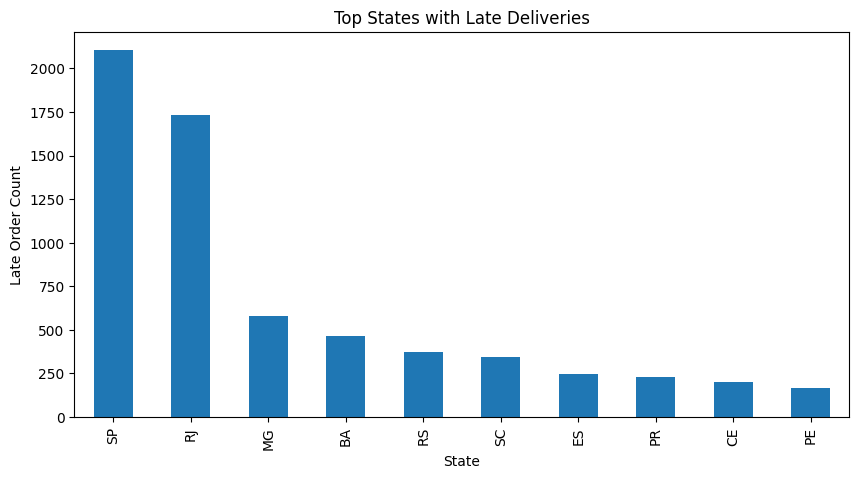

In [ ]:
late_by_state = (
    merged_df[merged_df["is_late"] == "Late"]
    .groupby("customer_state")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

late_by_state.plot(kind="bar")

plt.title("Top States with Late Deliveries")
plt.xlabel("State")
plt.ylabel("Late Order Count")

plt.show()

In [ ]:
merged_df["customer_state"].value_counts().head(10)

,count
customer_state,
SP,48816
RJ,14963
MG,13496
RS,6431
PR,5894
SC,4239
BA,3950
DF,2447
GO,2395


In [ ]:
late_rate = (
    merged_df
    .groupby("customer_state")["is_late"]
    .apply(lambda x: (x == "Late").mean() * 100)
    .sort_values(ascending=False)
)

late_rate.head(10)

,is_late
customer_state,
AL,21.348315
MA,17.861482
SE,15.803109
PI,13.898917
CE,13.430851
BA,11.797468
RJ,11.588585
PA,11.121240
PB,11.057692


In [ ]:
sp_rj = merged_df[
    merged_df["customer_state"].isin(["SP", "RJ"])
]

In [ ]:
(
    sp_rj["customer_state"]
    != sp_rj["seller_state"]
).mean() * 100

np.float64(39.96142931058812)

###Ürün ağırlığına göre ürün maliyet değişimi

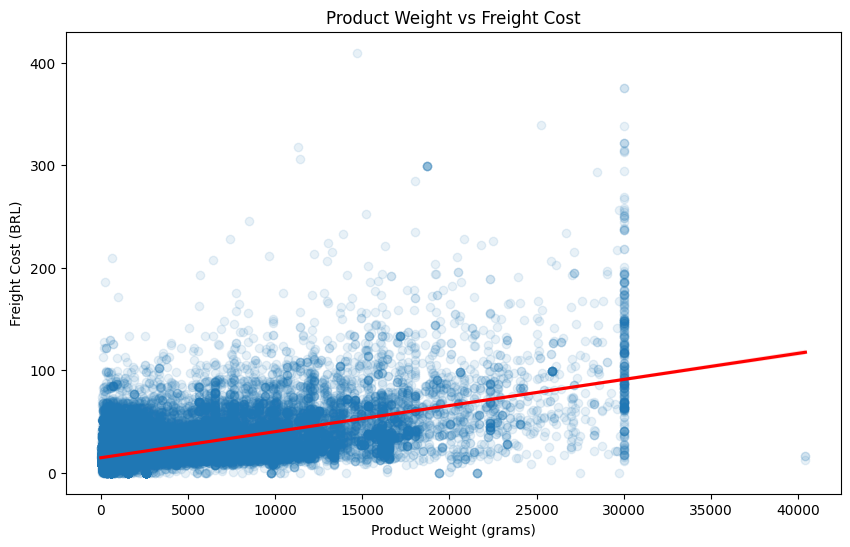

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=merged_df,
    x="product_weight_g",
    y="freight_value",
    scatter_kws={"alpha":0.1},
    line_kws={"color":"red"}
)

plt.title("Product Weight vs Freight Cost")
plt.xlabel("Product Weight (grams)")
plt.ylabel("Freight Cost (BRL)")

plt.show()


#Korelasyon Analizleri

##Kargo Bilgisi

In [ ]:
df = orders_delivered.merge(customers, on="customer_id", how="left")
df = df.merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
df = df.merge(order_items[["order_id", "product_id", "seller_id", "price", "freight_value"]], on="order_id", how="left")
df = df.merge(products[["product_id", "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]], on="product_id", how="left")
df = df.merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")

In [ ]:
df["product_volume_cm3"] = (
df["product_length_cm"] *
df["product_height_cm"] *
df["product_width_cm"]
)

df["same_state"] = np.where(
df["customer_state"] == df["seller_state"],
"Same State",
"Different State"
)

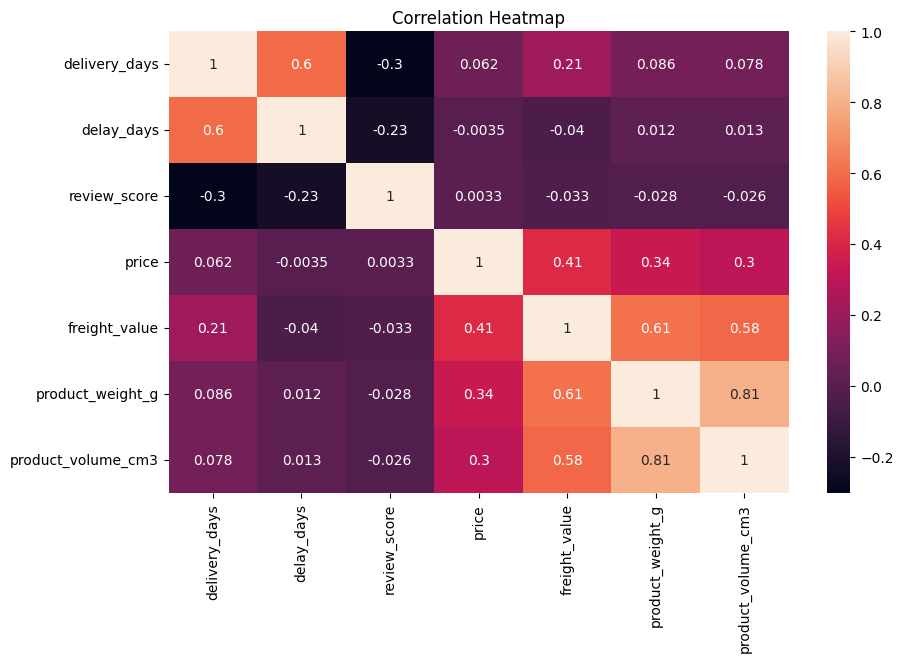

In [ ]:
corr_columns = [
"delivery_days",
"delay_days",
"review_score",
"price",
"freight_value",
"product_weight_g",
"product_volume_cm3"
]

corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

##Ürün ve Sipariş

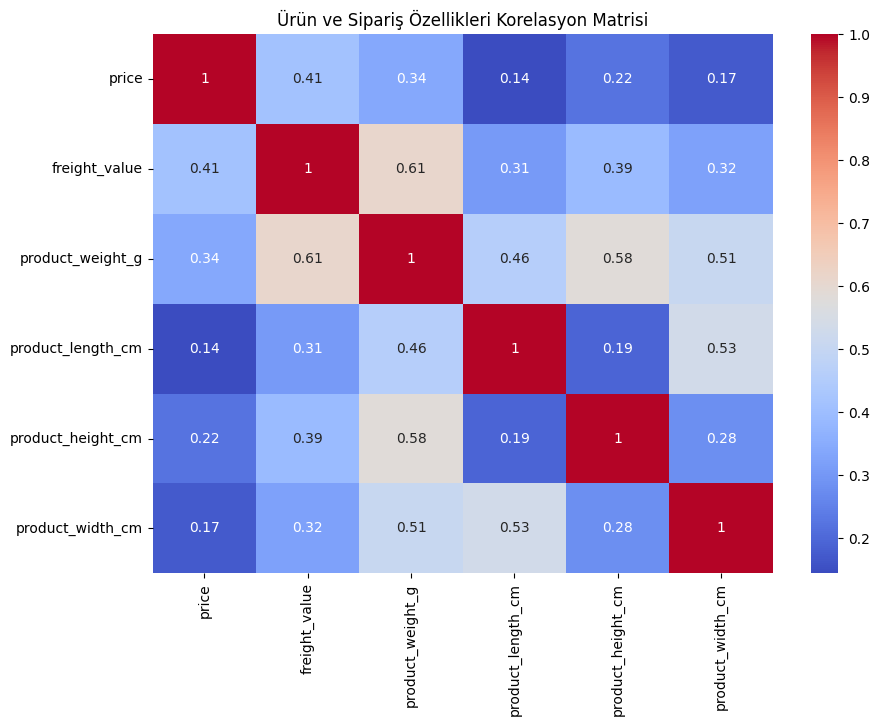

In [ ]:
corr_df = df_delivered[
    [
        'price',
        'freight_value',
        'product_weight_g',
        'product_length_cm',
        'product_height_cm',
        'product_width_cm'
    ]
]
corr_matrix = corr_df.corr()
plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Ürün ve Sipariş Özellikleri Korelasyon Matrisi')
plt.show()

Korelasyon analizi sonucunda ürün ağırlığı ile kargo maliyeti arasında güçlü pozitif ilişki olduğu görülmüştür (r=0.61). Bu durum ağır ürünlerin lojistik maliyetlerini artırdığını göstermektedir.

Ayrıca ürün boyut değişkenleri arasında orta seviyede pozitif ilişkiler bulunmuştur. Buna karşılık ürün fiyatı ile fiziksel boyutlar arasındaki ilişkilerin daha zayıf olduğu gözlemlenmiştir. Bu durum fiyatın yalnızca ürün boyutlarından değil kategori, marka ve ürün segmenti gibi farklı faktörlerden de etkilendiğini göstermektedir.

#Testler

##1-Müşteri Davranışı

1.

H0: Ödeme yöntemi müşteri memnuniyetini etkilemez.

H1: Ödeme yöntemi müşteri memnuniyetini etkiler.

In [ ]:
import scipy.stats as stats

credit_card = payment_reviews[payment_reviews["payment_type"] == "credit_card"]["review_score"]
boleto = payment_reviews[payment_reviews["payment_type"] == "boleto"]["review_score"]
voucher = payment_reviews[payment_reviews["payment_type"] == "voucher"]["review_score"]
debit_card = payment_reviews[payment_reviews["payment_type"] == "debit_card"]["review_score"]

f_score, p_value = stats.f_oneway(
    credit_card,
    boleto,
    voucher,
    debit_card
)

print("F-score:", f_score)
print("p-value:", p_value)

F-score: 9.003601355223331
p-value: 5.866316838531612e-06


*ANOVA testi için ödeme yöntemleri gruplara ayrıldı ve her grubun review score değerleri ayrı ayrı seçildi.*

p-value değeri 0.05’ten küçük çıktığı için H0 hipotezi reddedildi. Sonuç olarak ödeme yönteminin müşteri memnuniyeti üzerinde anlamlı bir etkisi olduğu görüldü.

2.

H0: Taksitli ve taksitsiz ödemelerde müşteri memnuniyeti aynıdır.

H1: Taksitsiz ödemelerde müşteri memnuniyeti daha yüksektir.

In [ ]:
import scipy.stats as stats

no_installment = payment_reviews[payment_reviews["payment_installments"] == 0]["review_score"]
with_installment = payment_reviews[payment_reviews["payment_installments"] > 0]["review_score"]

t_score, p_value = stats.ttest_ind(no_installment, with_installment)

print("T-score:", t_score)
print("p-value:", p_value)

T-score: 0.9602786073807297
p-value: 0.3369172532235799


*T-testi sonucunda p-value değeri 0.05’ten büyük çıktığı için H0 hipotezi reddedilemedi. Bu sonuca göre taksitli ve taksitsiz ödemeler arasında müşteri memnuniyeti açısından istatistiksel olarak anlamlı bir fark bulunmadı. T-score değerinin düşük çıkması da iki grubun ortalama memnuniyet puanlarının birbirine yakın olduğunu gösteriyor.*

3:

H0: Teslimat süresi müşteri memnuniyetini etkilemez.

H1: Uzun teslimat süreleri müşteri memnuniyetini düşürür.

In [ ]:
correlation = delivery_reviews["delivery_days"].corr(delivery_reviews["review_score"])

print("Correlation:", correlation)

Correlation: -0.333660341104771


0'a yakın → ilişki zayıf

1'e yakın → güçlü pozitif ilişki

-1'e yakın → güçlü negatif ilişki

Korelasyon analizi sonucunda delivery_days ile review_score arasında yaklaşık -0.3 seviyesinde negatif bir ilişki bulundu.

 -0.3 değeri, teslimat süresi ile müşteri memnuniyeti arasında zayıf-orta seviyede negatif bir ilişki olduğunu göstermektedir.

 Sonuç olarak teslimat süresi arttıkça müşteri memnuniyeti düşme eğilimi göstermektedir.

##2-Ürün ve Sipariş

In [ ]:
bed = df_delivered[
    df_delivered['product_category_name'] == 'beleza_saude'
]['price']

sports = df_delivered[
    df_delivered['product_category_name'] == 'relogios_presentes'
]['price']

furniture = df_delivered[
    df_delivered['product_category_name'] == 'cama_mesa_banho'
]['price']
from scipy.stats import f_oneway

f_oneway(
    bed,
    sports,
    furniture
)

F_onewayResult(statistic=np.float64(738.028472840217), pvalue=np.float64(1.438987974906e-312))

Test sonucunda elde edilen p-değerinin 0.05’ten oldukça küçük olması nedeniyle null hipotezi reddedilmiştir. Bu sonuç, ürün kategorileri arasında ortalama fiyat açısından istatistiksel olarak anlamlı fark bulunduğunu göstermektedir.

Özellikle farklı ürün segmentlerinin farklı fiyat seviyelerinde konumlandığı görülmektedir. Bu durum kategori bazlı fiyatlandırma stratejilerinin önemli olduğunu göstermektedir.

##3-Kargo Bilgisi

###Teslimat Performansının müşteri memnuniyetine etkisi

H0: Geç teslimat müşteri memnuniyetini etkilemez.

H1: Geç teslimat müşteri memnuniyetini etkiler.

In [ ]:
late_reviews = df[df["is_late"] == "Late"]["review_score"].dropna()
ontime_reviews = df[df["is_late"] == "On Time or Early"]["review_score"].dropna()

t_stat, p_value = stats.ttest_ind(late_reviews, ontime_reviews, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
 print("H0 reddedilir. Geç teslimat ile müşteri memnuniyeti arasında anlamlı fark vardır.")
else:
 print("H0 reddedilemez. Anlamlı fark bulunamamıştır.")

T-statistic: -102.5289153934592
P-value: 0.0
H0 reddedilir. Geç teslimat ile müşteri memnuniyeti arasında anlamlı fark vardır.


###Eyaletlere göre teslim süresinin değişmesi ilişkili midir? -Anova Test

In [ ]:
top_states = merged_df["customer_state"].value_counts().head(5).index

top_states

Index(['SP', 'RJ', 'MG', 'RS', 'PR'], dtype='object', name='customer_state')

In [ ]:
anova_df = merged_df[
    merged_df["customer_state"].isin(top_states)
]

In [ ]:
groups = []

for state in top_states:
    group = anova_df[
        anova_df["customer_state"] == state
    ]["delivery_days"].dropna()

    groups.append(group)

In [ ]:
from scipy.stats import f_oneway

In [ ]:
anova_result = f_oneway(*groups)

print(anova_result)

F_onewayResult(statistic=np.float64(2569.15347621505), pvalue=np.float64(0.0))


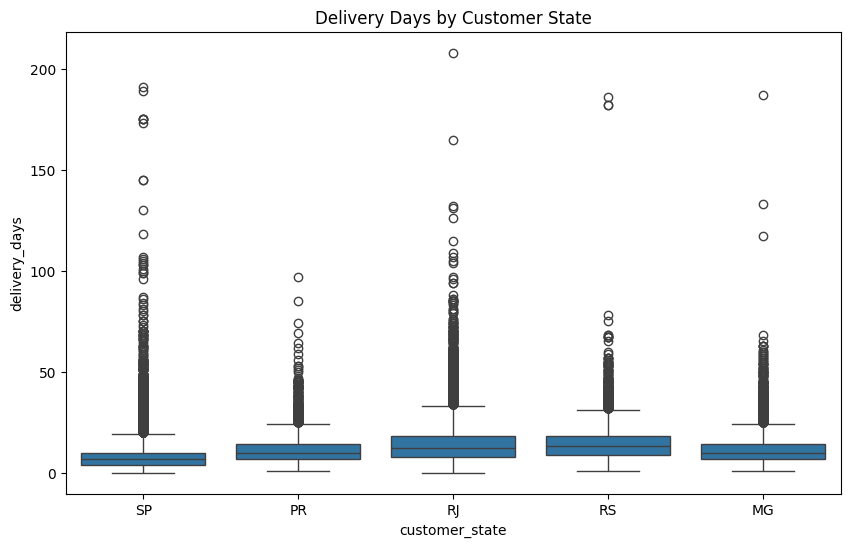

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=anova_df,
    x="customer_state",
    y="delivery_days"
)

plt.title("Delivery Days by Customer State")
plt.show()

#Sonuçlar & içgörüler

Bu analiz sonucunda teslimat performansının müşteri memnuniyeti üzerinde önemli bir etkisi olduğu görülmüştür. Özellikle lokasyon bazlı lojistik farklılıklar, teslim süreleri ve kargo maliyetlerinde değişim yaratmaktadır. Ayrıca ürün ağırlığı ve satıcı performansı gibi faktörlerin operasyonel süreçleri etkilediği gözlemlenmiştir. Analizler, müşteri deneyimini iyileştirmek için lojistik optimizasyonu ve satıcı performans takibinin kritik olduğunu göstermektedir.